In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df=pd.read_csv('Exam_Score_Prediction.csv')

In [3]:
df

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19997,18,other,bba,6.50,71.3,yes,5.0,good,self-study,low,easy,86.5
19996,19998,18,male,b.com,3.71,41.6,no,5.9,average,coaching,medium,moderate,60.9
19997,19999,19,other,diploma,7.88,68.2,yes,4.6,poor,group study,low,easy,64.5
19998,20000,19,male,bba,4.60,76.3,no,6.1,good,self-study,medium,moderate,79.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
student_id,20000.0,10000.504600,5773.654959,1.000,5000.75,10000.50,15000.25,20001.00
age,20000.0,20.473300,2.284458,17.000,18.00,20.00,22.00,24.00
study_hours,20000.0,4.007604,2.308313,0.080,2.00,4.04,6.00,7.91
class_attendance,20000.0,70.017365,17.282262,40.600,55.10,69.90,85.00,99.40
sleep_hours,20000.0,7.008560,1.732090,4.100,5.50,7.00,8.50,9.90
exam_score,20000.0,62.513225,18.908491,19.599,48.80,62.60,76.30,100.00


In [6]:
df.nunique()

student_id          20000
age                     8
gender                  3
course                  7
study_hours           784
class_attendance      589
internet_access         2
sleep_hours            59
sleep_quality           3
study_method            5
facility_rating         3
exam_difficulty         3
exam_score            805
dtype: int64

In [7]:
df[df['exam_score']<50]

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7
7,8,22,male,b.sc,5.48,51.1,yes,8.2,poor,self-study,low,moderate,47.3
8,9,18,other,bca,2.89,92.0,yes,6.6,poor,self-study,low,easy,44.9
13,14,23,female,bba,0.81,66.0,yes,7.1,poor,online videos,medium,moderate,34.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19981,19983,19,female,b.com,1.47,92.1,yes,8.4,average,self-study,low,moderate,44.1
19984,19986,22,other,ba,1.24,94.1,yes,7.6,poor,mixed,medium,moderate,49.6
19987,19989,18,male,b.com,2.05,46.2,yes,6.5,good,self-study,high,moderate,48.0
19988,19990,20,female,ba,0.33,96.1,no,6.4,good,online videos,high,easy,46.7


In [8]:
'''
student_id has to be object
'''

'\nstudent_id has to be object\n'

In [9]:
df['student_id']=df['student_id'].astype(object)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  object 
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 2.0+ MB


In [11]:
df['gender'].value_counts()

gender
other     6726
male      6695
female    6579
Name: count, dtype: int64

In [12]:
df['gender']=df['gender'].replace('other','male')

In [13]:
df['gender'].value_counts()

gender
male      13421
female     6579
Name: count, dtype: int64

In [14]:
df['course'].value_counts()

course
bca        2902
ba         2896
b.sc       2878
b.com      2864
bba        2836
diploma    2826
b.tech     2798
Name: count, dtype: int64

In [15]:
df['sleep_quality'].value_counts()

sleep_quality
average    6694
poor       6687
good       6619
Name: count, dtype: int64

In [16]:
df['exam_score'].max()

100.0

In [17]:
df=df.drop('student_id',axis=1)

In [18]:
x=df.drop('exam_score',axis=1)
y=df['exam_score']

In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
x_train

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
5894,21,male,b.com,6.87,57.1,no,9.0,good,group study,low,hard
3728,19,male,ba,6.91,54.8,yes,9.1,good,mixed,medium,hard
8958,20,male,ba,5.45,99.4,yes,7.6,average,group study,medium,moderate
7671,20,male,ba,4.73,47.6,yes,7.0,poor,group study,high,moderate
5999,17,female,bca,3.81,78.6,yes,7.8,good,group study,high,moderate
...,...,...,...,...,...,...,...,...,...,...,...
11284,22,female,b.com,7.36,98.8,yes,7.1,poor,mixed,medium,hard
11964,19,male,bba,5.83,99.0,yes,9.6,poor,self-study,high,easy
5390,18,male,ba,1.49,80.1,yes,7.1,good,mixed,medium,moderate
860,24,male,bca,0.28,52.1,yes,7.1,good,online videos,high,moderate


In [21]:
y_train.describe().T

count    16000.000000
mean        62.543159
std         18.907275
min         19.599000
25%         48.800000
50%         62.700000
75%         76.300000
max        100.000000
Name: exam_score, dtype: float64

In [22]:
x_train_cat=x_train.select_dtypes(exclude=['int','float'])
x_train_cont=x_train.select_dtypes(exclude=['object'])

In [23]:
x_test_cat=x_test.select_dtypes(exclude=['int','float'])
x_test_cont=x_test.select_dtypes(exclude=['object'])

In [24]:
from sklearn.preprocessing import OneHotEncoder
OHE=OneHotEncoder( sparse_output=False ,drop='first')
OHE.fit(x_train_cat)

OneHotEncoder(drop='first', sparse_output=False)

In [25]:
X_train_cat_encoded = pd.DataFrame(data = OHE.transform(x_train_cat),
             columns = OHE.get_feature_names_out(),
             index = x_train_cat.index)

x_test_cat_encoded = pd.DataFrame(data = OHE.transform(x_test_cat),
             columns = OHE.get_feature_names_out(),
             index = x_test_cat.index)

In [26]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(x_train_cont)

StandardScaler()

In [27]:
X_train_cont_S = pd.DataFrame(data = scaler.transform(x_train_cont),
             columns = x_train_cont.columns+'_S',
             index = x_train_cat.index)

X_test_cont_S = pd.DataFrame(data = scaler.transform(x_test_cont),
             columns = x_test_cont.columns + '_S',
             index = x_test_cont.index)

In [28]:
x_train_comb = pd.concat([X_train_cat_encoded, X_train_cont_S], axis = 1)
x_test_comb = pd.concat([x_test_cat_encoded, X_test_cont_S], axis = 1)

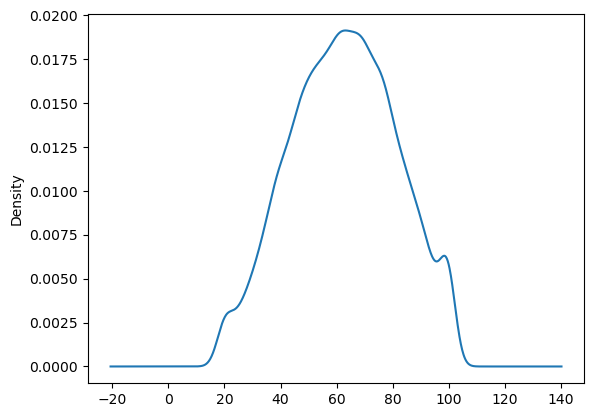

In [29]:
y_train.plot.kde()
plt.show()

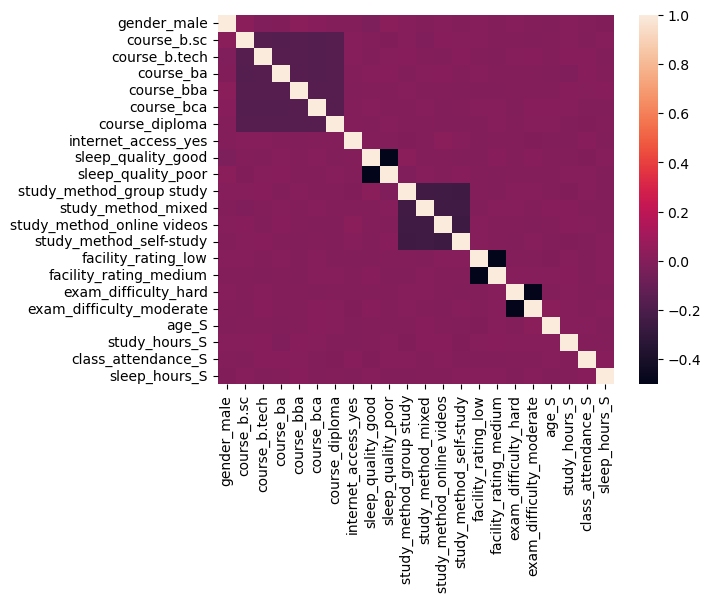

In [30]:
sns.heatmap(x_train_comb.corr())
plt.show()

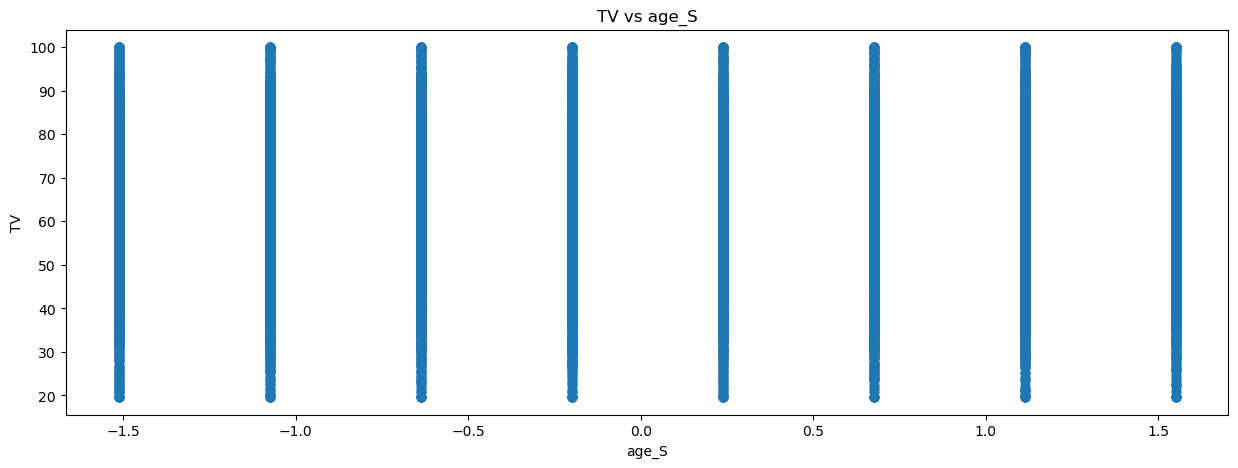

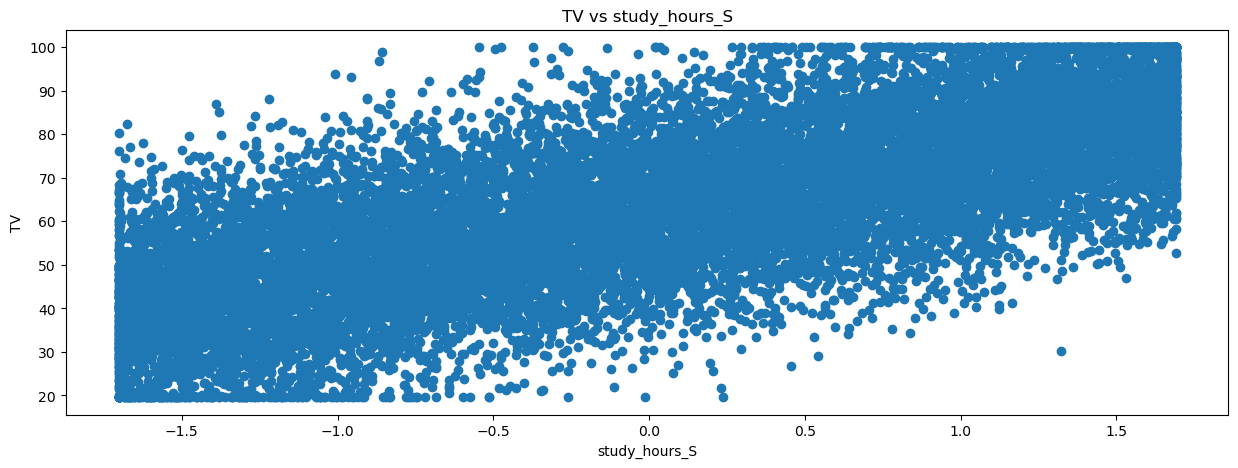

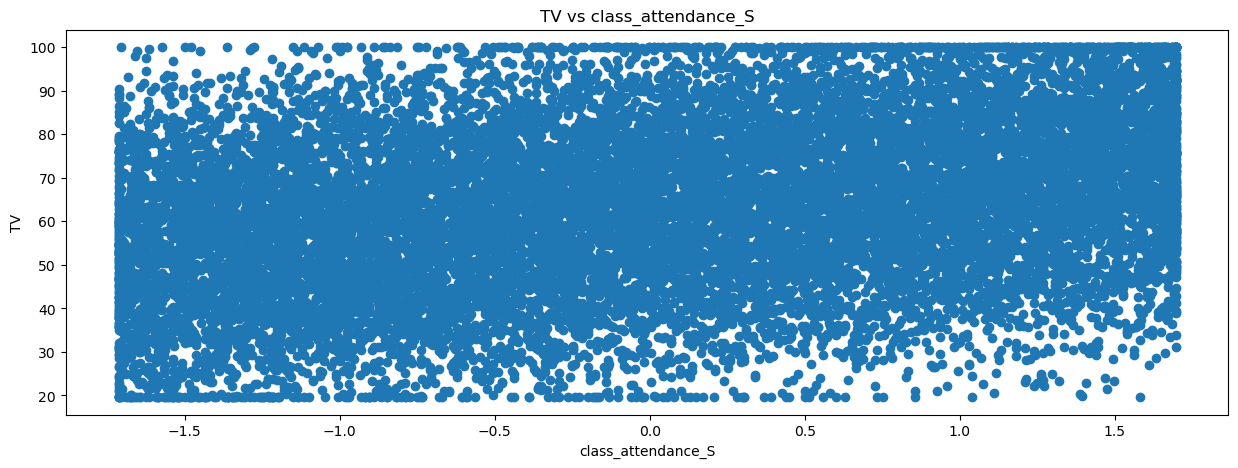

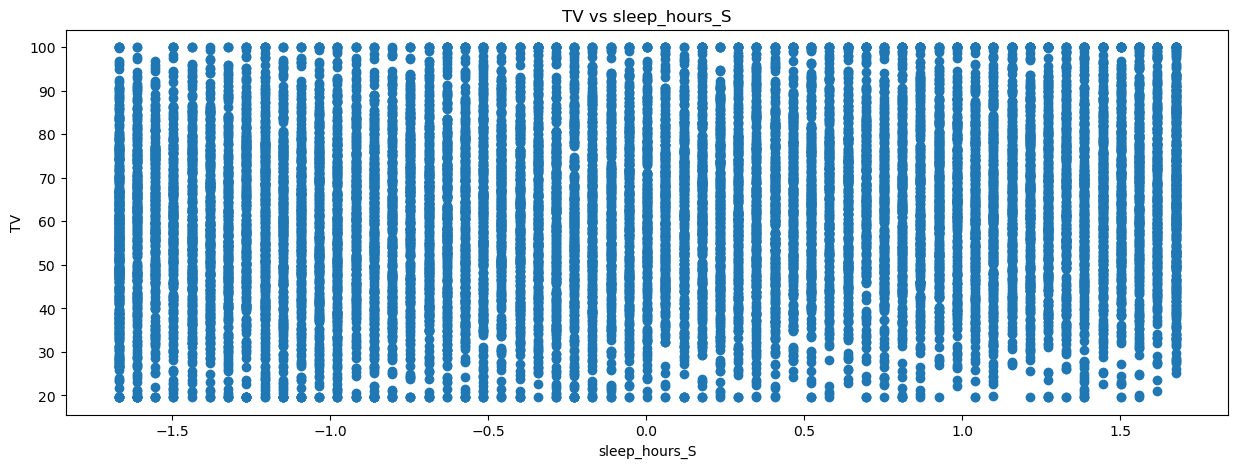

In [31]:
cols = x_train_cont.columns + '_S'
for col in cols:
    plt.figure(figsize = [15,5])
    plt.scatter(x = x_train_comb[col], y = y_train)
    plt.title('TV vs ' + col)
    plt.xlabel(col)
    plt.ylabel('TV')
    plt.show()

In [32]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(x_train_comb, y_train)

LinearRegression()

In [33]:
reg.predict(x_test_comb)

array([36.71667343, 79.95922299, 54.35527472, ..., 61.83308638,
       62.83443773, 52.67367725])

In [34]:
prediction_L=pd.DataFrame( data=reg.predict(x_test_comb),
                        columns = ['liner'],
                       index=x_test_comb.index)

In [35]:
prediction_L

,liner
10650,36.716673
2041,79.959223
8668,54.355275
1114,102.146536
13902,80.633601
...,...
4073,49.051541
7442,33.884889
9999,61.833086
1870,62.834438


In [36]:
prediction_L[prediction_L['liner']>100]

,liner
1114,102.146536
15983,105.190837
18466,101.413225
5817,105.560741
8797,101.597141
9842,102.619866
4463,100.822683
230,100.263834
12767,111.086011
2624,104.261907


In [37]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train_comb,y_train)

KNeighborsRegressor()

In [38]:
knn.predict(x_test_comb)

array([45.22, 76.84, 47.96, ..., 62.4 , 70.52, 56.42])

In [39]:
prediction_knn=pd.DataFrame( data=knn.predict(x_test_comb),
                        columns = ['knn'],
                       index=x_test_comb.index)

In [40]:
prediction_knn[prediction_knn['knn']>100]

,knn


In [41]:
from sklearn.tree import DecisionTreeRegressor


In [42]:
from sklearn.model_selection import  RandomizedSearchCV

dt = DecisionTreeRegressor(random_state=42)

param_dist = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8,9,10,11,12,13],
    'min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9, 10,11,12,13]
}

random_search = RandomizedSearchCV(dt, param_dist)
random_search.fit(x_train_comb, y_train)

print("\nBest parameters (Random Search):", random_search.best_params_)
print("Best score (Random Search):", random_search.best_score_)


Best parameters (Random Search): {'min_samples_split': 10, 'max_depth': 8}
Best score (Random Search): 0.6341065347399599


In [43]:
DT = DecisionTreeRegressor(max_depth=7)
DT.fit(x_train_comb, y_train)

DecisionTreeRegressor(max_depth=7)

In [44]:
DT.predict(x_test_comb)

array([35.95909859, 74.12022472, 60.78012821, ..., 69.67940299,
       73.14926686, 49.16473048])

In [45]:
prediction_DT=pd.DataFrame( data=DT.predict(x_test_comb),
                        columns = ['DT'],
                       index=x_test_comb.index)

In [46]:
prediction_DT

,DT
10650,35.959099
2041,74.120225
8668,60.780128
1114,93.767932
13902,77.390698
...,...
4073,62.384286
7442,32.061339
9999,69.679403
1870,73.149267


In [47]:
prediction_DT[prediction_DT['DT']>100]

,DT


In [48]:
from sklearn.ensemble import RandomForestRegressor
RF = RandomForestRegressor()
RF.fit(x_train_comb,y_train)

RandomForestRegressor()

In [49]:
prediction_RF=pd.DataFrame( data=RF.predict(x_test_comb),
                        columns = ['RF'],
                       index=x_test_comb.index)

In [50]:
prediction_RF

,RF
10650,37.14098
2041,74.47800
8668,58.09500
1114,94.95000
13902,85.56200
...,...
4073,56.91200
7442,32.31295
9999,67.56900
1870,73.27700


In [51]:
prediction_RF[prediction_RF['RF']>100]

,RF


In [52]:
prediction = pd.concat([prediction_L, prediction_knn,prediction_DT,prediction_RF], axis=1)

In [53]:
prediction

,liner,knn,DT,RF
10650,36.716673,45.22,35.959099,37.14098
2041,79.959223,76.84,74.120225,74.47800
8668,54.355275,47.96,60.780128,58.09500
1114,102.146536,94.28,93.767932,94.95000
13902,80.633601,71.98,77.390698,85.56200
...,...,...,...,...
4073,49.051541,64.80,62.384286,56.91200
7442,33.884889,43.08,32.061339,32.31295
9999,61.833086,62.40,69.679403,67.56900
1870,62.834438,70.52,73.149267,73.27700


# LINAER

In [54]:
y_test_pre=reg.predict(x_test_comb)
y_train_pre=reg.predict(x_train_comb)

from sklearn.metrics import mean_absolute_error
LINEAR_EVAL_train_MAE = mean_absolute_error(y_train, y_train_pre)
LINEAR_EVAL_test_MAE= mean_absolute_error(y_test, y_test_pre)

from sklearn.metrics import mean_squared_error
LINEAR_EVAL_train_MSE = mean_absolute_error(y_train, y_train_pre)
LINEAR_EVAL_test_MSE = mean_absolute_error(y_test, y_test_pre)

from sklearn.metrics import root_mean_squared_error
LINEAR_EVAL_train_RMAE = root_mean_squared_error(y_train, y_train_pre)
LINEAR_EVAL_test_RMAE = root_mean_squared_error(y_test, y_test_pre)

from sklearn.metrics import mean_absolute_percentage_error
LINEAR_EVAL_train_MAPE = mean_absolute_percentage_error(y_train, y_train_pre)
LINEAR_EVAL_test_MAPE = mean_absolute_percentage_error(y_test, y_test_pre)

from sklearn.metrics import r2_score
LINEAR_EVAL_train_R2 = r2_score(y_train, y_train_pre)
LINEAR_EVAL_test_R2 = r2_score(y_test, y_test_pre)

In [55]:
comparison_LINEAR = pd.DataFrame({
    "MAE":  [LINEAR_EVAL_train_MAE,  LINEAR_EVAL_test_MAE],
    "MSE":  [LINEAR_EVAL_train_MSE,  LINEAR_EVAL_test_MSE],
    "RMSE": [LINEAR_EVAL_train_RMAE, LINEAR_EVAL_test_RMAE],
    "MAPE": [LINEAR_EVAL_train_MAPE, LINEAR_EVAL_test_MAPE],
    "R2":   [LINEAR_EVAL_train_R2,   LINEAR_EVAL_test_R2],
}, index=["Train", "Test"])

In [56]:
comparison_LINEAR

,MAE,MSE,RMSE,MAPE,R2
Train,7.850077,7.850077,9.788580,0.146136,0.731954
Test,7.862396,7.862396,9.771998,0.146545,0.733037


# KNN

In [57]:
y_test_pre=knn.predict(x_test_comb)
y_train_pre=knn.predict(x_train_comb)

from sklearn.metrics import mean_absolute_error
KNN_EVAL_train_MAE = mean_absolute_error(y_train, y_train_pre)
KNN_EVAL_test_MAE = mean_absolute_error(y_test, y_test_pre)

from sklearn.metrics import mean_squared_error
KNN_EVAL_train_MSE = mean_absolute_error(y_train, y_train_pre)
KNN_EVAL_test_MSE = mean_absolute_error(y_test, y_test_pre)

from sklearn.metrics import root_mean_squared_error
KNN_EVAL_train_RMAE = root_mean_squared_error(y_train, y_train_pre)
KNN_EVAL_test_RMAE = root_mean_squared_error(y_test, y_test_pre)

from sklearn.metrics import mean_absolute_percentage_error
KNN_EVAL_train_MAPE = mean_absolute_percentage_error(y_train, y_train_pre)
KNN_EVAL_test_MAPE = mean_absolute_percentage_error(y_test, y_test_pre)

from sklearn.metrics import r2_score
KNN_EVAL_train_R2 = r2_score(y_train, y_train_pre)
KNN_EVAL_test_R2 = r2_score(y_test, y_test_pre)

In [58]:
comparison_KNN = pd.DataFrame({
    "MAE":  [KNN_EVAL_train_MAE,  KNN_EVAL_test_MAE],
    "MSE":  [KNN_EVAL_train_MSE,  KNN_EVAL_test_MSE],
    "RMSE": [KNN_EVAL_train_RMAE, KNN_EVAL_test_RMAE],
    "MAPE": [KNN_EVAL_train_MAPE, KNN_EVAL_test_MAPE],
    "R2":   [KNN_EVAL_train_R2,   KNN_EVAL_test_R2],
}, index=["Train", "Test"])

In [59]:
comparison_KNN

,MAE,MSE,RMSE,MAPE,R2
Train,7.658138,7.658138,9.561939,0.144610,0.744223
Test,9.305029,9.305029,11.556427,0.176931,0.626637


# DT

In [60]:
y_test_pre=DT.predict(x_test_comb)
y_train_pre=DT.predict(x_train_comb)

from sklearn.metrics import mean_absolute_error
DT_EVAL_train_MAE = mean_absolute_error(y_train, y_train_pre)
DT_EVAL_test_MAE = mean_absolute_error(y_test, y_test_pre)

from sklearn.metrics import mean_squared_error
DT_EVAL_train_MSE = mean_absolute_error(y_train, y_train_pre)
DT_EVAL_test_MSE = mean_absolute_error(y_test, y_test_pre)

from sklearn.metrics import root_mean_squared_error
DT_EVAL_train_RMAE = root_mean_squared_error(y_train, y_train_pre)
DT_EVAL_test_RMAE = root_mean_squared_error(y_test, y_test_pre)

from sklearn.metrics import mean_absolute_percentage_error
DT_EVAL_train_MAPE = mean_absolute_percentage_error(y_train, y_train_pre)
DT_EVAL_test_MAPE = mean_absolute_percentage_error(y_test, y_test_pre)

from sklearn.metrics import r2_score
DT_EVAL_train_R2 = r2_score(y_train, y_train_pre)
DT_EVAL_test_R2 = r2_score(y_test, y_test_pre)

In [61]:
comparison_DT = pd.DataFrame({
    "MAE":  [DT_EVAL_train_MAE,  DT_EVAL_test_MAE],
    "MSE":  [DT_EVAL_train_MSE,  DT_EVAL_test_MSE],
    "RMSE": [DT_EVAL_train_RMAE, DT_EVAL_test_RMAE],
    "MAPE": [DT_EVAL_train_MAPE, DT_EVAL_test_MAPE],
    "R2":   [DT_EVAL_train_R2,   DT_EVAL_test_R2],
}, index=["Train", "Test"])

In [62]:
comparison_DT

,MAE,MSE,RMSE,MAPE,R2
Train,8.679317,8.679317,10.821625,0.161816,0.672392
Test,9.220812,9.220812,11.389289,0.173130,0.637358


# RF

In [63]:
y_test_pre=RF.predict(x_test_comb)
y_train_pre=RF.predict(x_train_comb)

from sklearn.metrics import mean_absolute_error
RF_EVAL_train_MAE = mean_absolute_error(y_train, y_train_pre)
RF_EVAL_test_MAE = mean_absolute_error(y_test, y_test_pre)

from sklearn.metrics import mean_squared_error
RF_EVAL_train_MSE = mean_absolute_error(y_train, y_train_pre)
RF_EVAL_test_MSE = mean_absolute_error(y_test, y_test_pre)

from sklearn.metrics import root_mean_squared_error
RF_EVAL_train_RMAE = root_mean_squared_error(y_train, y_train_pre)
RF_EVAL_test_RMAE = root_mean_squared_error(y_test, y_test_pre)

from sklearn.metrics import mean_absolute_percentage_error
RF_EVAL_train_MAPE = mean_absolute_percentage_error(y_train, y_train_pre)
RF_EVAL_test_MAPE = mean_absolute_percentage_error(y_test, y_test_pre)

from sklearn.metrics import r2_score
RF_EVAL_train_R2 = r2_score(y_train, y_train_pre)
RF_EVAL_test_R2 = r2_score(y_test, y_test_pre)

In [64]:
comparison_RF = pd.DataFrame({
    "MAE":  [RF_EVAL_train_MAE,  RF_EVAL_test_MAE],
    "MSE":  [RF_EVAL_train_MSE,  RF_EVAL_test_MSE],
    "RMSE": [RF_EVAL_train_RMAE, RF_EVAL_test_RMAE],
    "MAPE": [RF_EVAL_train_MAPE, RF_EVAL_test_MAPE],
    "R2":   [RF_EVAL_train_R2,   RF_EVAL_test_R2],
}, index=["Train", "Test"])

In [65]:
comparison_RF

,MAE,MSE,RMSE,MAPE,R2
Train,3.163085,3.163085,3.968481,0.059072,0.955943
Test,8.573728,8.573728,10.629081,0.161366,0.684153


In [66]:
comparison_LINEAR

,MAE,MSE,RMSE,MAPE,R2
Train,7.850077,7.850077,9.788580,0.146136,0.731954
Test,7.862396,7.862396,9.771998,0.146545,0.733037


In [67]:
comparison_KNN

,MAE,MSE,RMSE,MAPE,R2
Train,7.658138,7.658138,9.561939,0.144610,0.744223
Test,9.305029,9.305029,11.556427,0.176931,0.626637


In [68]:
comparison_DT

,MAE,MSE,RMSE,MAPE,R2
Train,8.679317,8.679317,10.821625,0.161816,0.672392
Test,9.220812,9.220812,11.389289,0.173130,0.637358


In [69]:
comparison_RF

,MAE,MSE,RMSE,MAPE,R2
Train,3.163085,3.163085,3.968481,0.059072,0.955943
Test,8.573728,8.573728,10.629081,0.161366,0.684153


# test 
MAPE = linear, 
RMSE = linear, 
R2 = linear, 
MAE = knn, 
MSE = knn, 
